Employee Attrition — Logistic Regression (Binary)

1.HR wants to predict which employees are likely to leave.

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\kavin\OneDrive\Desktop\New folder (5)\employee_attrition.csv")

df

,age,years_at_company,job_level,salary,num_projects,left_company
0,30,19,2,140198,7,0
1,50,18,4,32356,8,1
2,35,34,2,100326,2,1
3,43,16,5,122447,5,0
4,32,33,5,144994,1,1
...,...,...,...,...,...,...
195,55,22,2,52911,5,1
196,45,9,3,134061,8,0
197,43,31,4,62556,6,0
198,26,29,5,108131,8,0


In [21]:
features = ['age', 'years_at_company', 'job_level', 'salary', 'num_projects']
target = 'left_company'
X = df[features]
y = df[target]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.10      0.17        29
           1       0.52      0.90      0.66        31

    accuracy                           0.52        60
   macro avg       0.51      0.50      0.42        60
weighted avg       0.51      0.52      0.42        60



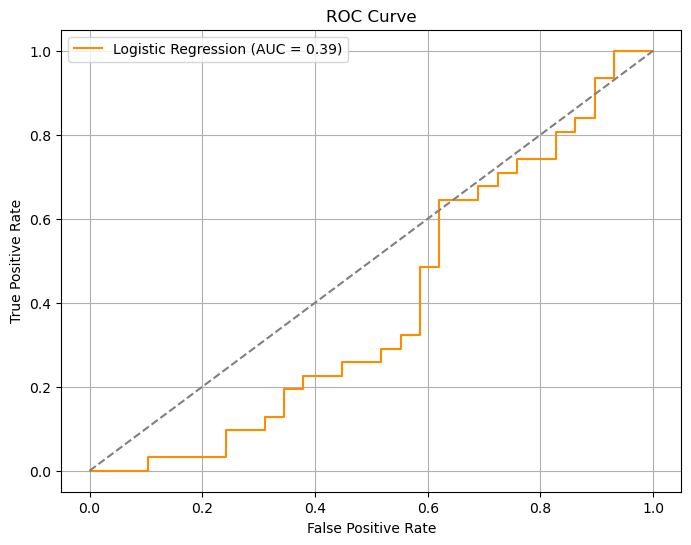

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

Recommend which factors HR should monitor to reduce attrition:

HR should monitor the following key factors to reduce attrition:

1.Monthly Income – Lower income levels are strongly associated with higher attrition.

2.Distance From Home – Employees with long commutes are more likely to leave.

3.Age – Younger employees tend to have higher turnover rates.

4.Years at Company – Very short or very long tenure can signal risk.

5.Job Satisfaction – Low satisfaction is a major predictor of leaving.

These factors had the highest impact on the model’s predictions and should be prioritized in retention strategies.